# 06 — Faithfulness and reliance: RQ3 (P4)

Does Qwen rely on the right features, and does the prior win?
The measurements are on the grid's label_diversity demonstration sets and the ID queries (`scripts/run_rq3.py`, `results/v3/synthetic/p4/rq3.parquet`).

- **π_true:** the generator's ground truth (positive for the 3 load-bearing columns, zero otherwise).
- **π_behav:** how much Qwen's correct-label margin drops when one column of the query is replaced by a donor row's value (hot-deck). The accuracy drop is shown alongside.
- **π_self:** Qwen's own ranking of the columns, asked after the same demonstrations.
- **Directional sensitivity:** each load-bearing column is nudged by ±0.5 SD. The response follows the data if the margin moves in the rule's direction, and follows the name if it moves in the name's direction. The demo-following index (DFI) is the share that follows the data.

Mechanistic probes (P6) will be added to this notebook later.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from src.utils.config import load_config, resolve_path  # first src import: sets the thread and MPS settings

config = load_config()

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data.suites import load_suite
from src.evaluation.analysis import (behavioural_importance, correctness_rho, dfi, directional_sensitivity,
                                     self_report_rho, true_importance_by_column)

RESULTS = resolve_path(config.paths.results)
P4 = RESULTS / "h200" / "p4"          # the P4 run (Runpod H200)
rq3 = pd.read_parquet(P4 / "rq3.parquet")
ranks = pd.read_parquet(P4 / "rq3_rankings.parquet")
# Re-parse the saved answers with the tolerant parser (underscores, hyphens, small spelling variants)
from src.experiments.rq3 import parse_ranking
names = {r.unit_key: dict(zip([f"f{j}" for j in range(10)], r.display_names)) for r in ranks.itertuples()}
parsed = [parse_ranking(r.response, names[r.unit_key]) for r in ranks.itertuples()]
ranks["ranking"], ranks["n_listed"] = [p[0] for p in parsed], [p[1] for p in parsed]
manifest = load_suite("eval", config)
truth = true_importance_by_column(manifest)
print(f"{rq3.unit_key.nunique()} units; namings {sorted(rq3.naming.unique())}; seeds {sorted(rq3.seed.unique())}")

from src.evaluation import plots

plots.use_style()

216 units; namings ['abstract', 'aligned', 'flipped']; seeds [np.int64(0), np.int64(1), np.int64(2)]


## 1. Which columns does Qwen rely on? (π_behav by column role)

In [2]:
bi = behavioural_importance(rq3)
t = bi.groupby(["naming", "feature_role"])[["margin_drop", "accuracy_drop"]].mean().unstack("naming")
display(t.round(3))

margin_drop                 accuracy_drop                
naming          abstract aligned flipped      abstract aligned flipped
feature_role                                                          
distractor        -0.016  -0.034  -0.009         0.002   0.001  -0.008
load_bearing       0.009   0.241  -0.047         0.005   0.029  -0.009
noise              0.035  -0.037   0.018         0.004  -0.002   0.004
spurious           0.141   0.085   0.081         0.010   0.001  -0.011

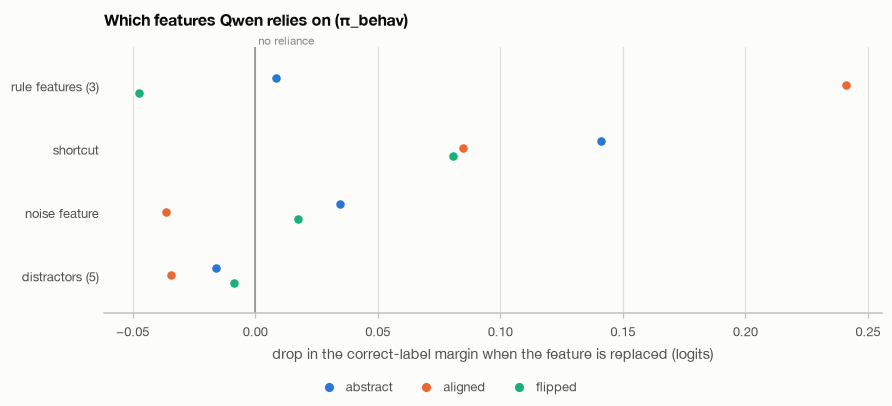

In [3]:
role_names = {"load_bearing": "rule features (3)", "spurious": "shortcut", "noise": "noise feature",
              "distractor": "distractors (5)"}
bm = bi.groupby(["feature_role", "naming"])["margin_drop"].mean().reset_index()
bm["role"] = bm["feature_role"].map(role_names)
fig, ax = plt.subplots(figsize=(8, 3.6), layout="constrained")
plots.dots(ax, bm, y="role", x="margin_drop", hue="naming", y_order=list(role_names.values()), hue_order=plots.NAMINGS,
           ref=0, ref_label="no reliance",
           xlabel="drop in the correct-label margin when the feature is replaced (logits)")
plots.legend_below(fig, plots.NAMINGS, plots.SERIES)
ax.set_title("Which features Qwen relies on (π_behav)")
plt.show()

**Reading the chart.** It shows how much Qwen's margin towards the correct label drops when one feature's value is swapped for another row's (larger means more reliance).
- **Abstract names:** Qwen leans on the shortcut (0.14) and barely on the rule features (0.01).
- **Aligned names** make the rule features matter most (0.24).
- **Flipped names:** the rule features turn negative (−0.05), so swapping them out *helps*, because Qwen reads them backwards.

## 2. Correctness: ρ(π_true, π_behav) by naming

In [4]:
rho = correctness_rho(rq3, truth)
display(rho.groupby("naming")["rho"].describe().round(3))
rho_acc = correctness_rho(rq3, truth, value="accuracy_drop")
print("accuracy-drop version:", rho_acc.groupby("naming")["rho"].mean().round(3).to_dict())

,count,mean,std,min,25%,50%,75%,max
naming,,,,,,,,
abstract,72.0,0.008,0.329,-0.798,-0.213,0.015,0.22,0.649
aligned,72.0,0.224,0.377,-0.798,-0.038,0.190,0.54,0.798
flipped,72.0,-0.007,0.338,-0.798,-0.262,0.007,0.25,0.753


accuracy-drop version: {'abstract': 0.024, 'aligned': 0.175, 'flipped': -0.009}


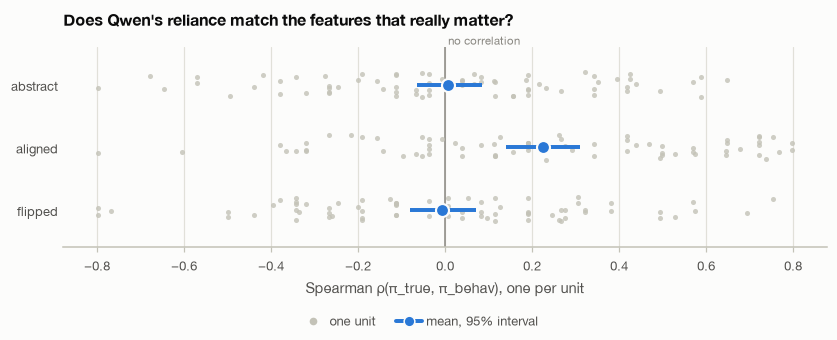

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 3), layout="constrained")
h = plots.strip(ax, rho, "naming", "rho", order=plots.NAMINGS, ref=0, ref_label="no correlation",
                xlabel="Spearman ρ(π_true, π_behav), one per unit")
plots.legend_below(fig, h)
ax.set_title("Does Qwen's reliance match the features that really matter?")
plt.show()

**Reading the chart.** Each grey dot is one unit (task × seed). Blue shows the mean with a bootstrap 95% interval.
- **Only aligned names put the mean clearly above 0** (0.22).
- **Abstract and flipped names sit at 0,** with units spread over almost the whole range.

## 3. Directional sensitivity and the demo-following index

In [6]:
d = dfi(rq3)
display(d.groupby("naming")[["follows_data", "follows_name"]].mean().round(3))
ds = directional_sensitivity(rq3)
lb = ds[ds.feature_role == "load_bearing"]
display(lb.groupby(["naming", "data_direction"])["follows_data"].mean().unstack("data_direction").round(3))
f8 = ds[ds.feature_role == "spurious"]
print("f8 nudges: share of responses moving in the task's spurious direction, by naming:",
      f8.groupby("naming")["follows_data"].mean().round(3).to_dict())

delta,follows_data,follows_name
naming,,
abstract,0.540,NaN
aligned,0.650,0.650
flipped,0.417,0.583


data_direction,-1,1
naming,,
abstract,0.448,0.631
aligned,0.613,0.686
flipped,0.317,0.516


f8 nudges: share of responses moving in the task's spurious direction, by naming: {'abstract': 0.592, 'aligned': 0.531, 'flipped': 0.561}


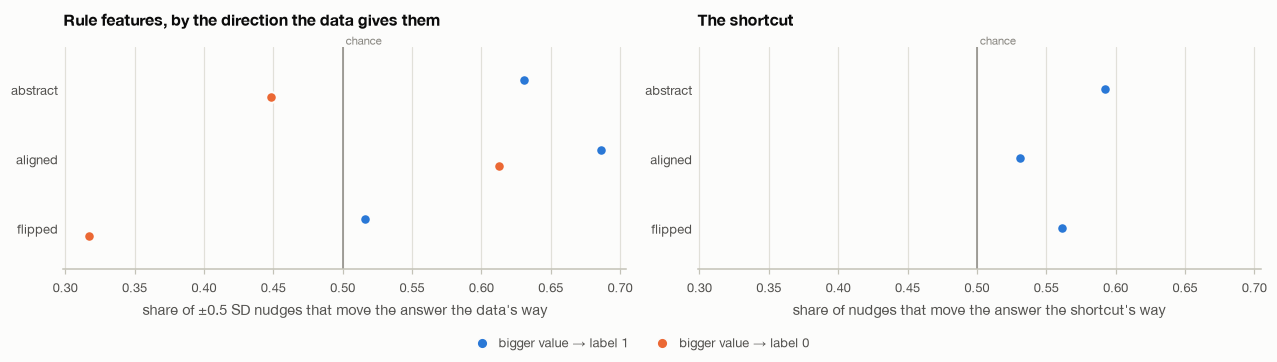

In [7]:
dd = lb.groupby(["naming", "data_direction"])["follows_data"].mean().reset_index()
dirs = {1: "bigger value → label 1", -1: "bigger value → label 0"}
dd["direction"] = dd["data_direction"].map(dirs)
f8m = f8.groupby("naming")["follows_data"].mean().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.2), sharex=True, layout="constrained")
plots.dots(axes[0], dd, y="naming", x="follows_data", hue="direction", y_order=plots.NAMINGS,
           hue_order=list(dirs.values()), ref=0.5, ref_label="chance",
           xlabel="share of ±0.5 SD nudges that move the answer the data's way")
plots.legend_below(fig, list(dirs.values()), plots.SERIES[:2])
axes[0].set_title("Rule features, by the direction the data gives them")
plots.dots(axes[1], f8m, y="naming", x="follows_data", y_order=plots.NAMINGS, ref=0.5, ref_label="chance",
           xlabel="share of nudges that move the answer the shortcut's way")
axes[1].set_title("The shortcut")
plt.show()

**Reading the charts.** Each rule feature was nudged by ±0.5 SD, and the chart counts how often Qwen's answer moved the way the data says it should.
- **Qwen follows upward features more readily than downward ones,** in every naming. That is the "bigger → 1" habit.
- **Under flipped names,** it follows downward rule features only 32% of the time.

Under flipped names, following the data and following the name are mutually exclusive: the name's direction is the opposite of the rule's.
The table by data direction shows the asymmetry found in P3: the conflict is stronger where a positive-sounding name sits on a feature whose larger values lower the label.

## 4. Self-report: π_self against π_behav

In [8]:
print("names listed per ranking:", ranks.groupby("naming")["n_listed"].describe().round(2).to_dict("index"))
sr = self_report_rho(ranks, rq3)
display(sr.groupby("naming")["rho"].describe().round(3))
with pd.option_context("display.max_colwidth", 200):
    display(ranks[["naming", "task_id", "response"]].head(6))

names listed per ranking: {'abstract': {'count': 72.0, 'mean': 10.0, 'std': 0.0, 'min': 10.0, '25%': 10.0, '50%': 10.0, '75%': 10.0, 'max': 10.0}, 'aligned': {'count': 72.0, 'mean': 10.0, 'std': 0.0, 'min': 10.0, '25%': 10.0, '50%': 10.0, '75%': 10.0, 'max': 10.0}, 'flipped': {'count': 72.0, 'mean': 10.0, 'std': 0.0, 'min': 10.0, '25%': 10.0, '50%': 10.0, '75%': 10.0, 'max': 10.0}}


,count,mean,std,min,25%,50%,75%,max
naming,,,,,,,,
abstract,72.0,-0.022,0.353,-0.636,-0.315,-0.030,0.230,0.782
aligned,72.0,0.119,0.351,-0.770,-0.082,0.121,0.370,0.818
flipped,72.0,-0.018,0.286,-0.612,-0.212,-0.006,0.167,0.539


,naming,task_id,response
0,abstract,eval_0000,"f3, f2, f4, f9, f8, f7, f6, f5, f1, f0"
1,abstract,eval_0003,"f8, f6, f3, f7, f2, f9, f4, f1, f0, f5"
2,abstract,eval_0006,"f8, f3, f6, f2, f7, f5, f1, f9, f4, f0"
3,abstract,eval_0009,"f3, f4, f2, f9, f8, f7, f6, f5, f1, f0"
4,abstract,eval_0012,"f5, f7, f3, f6, f0, f1, f8, f9, f2, f4"
5,abstract,eval_0015,"f4, f6, f9, f3, f7, f2, f5, f0, f1, f8"


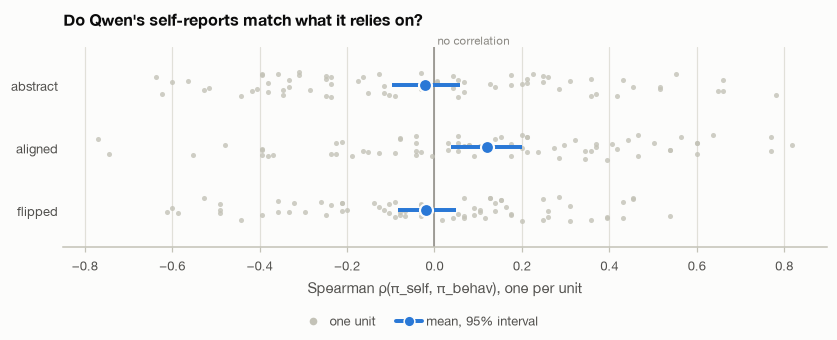

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 3), layout="constrained")
h = plots.strip(ax, sr, "naming", "rho", order=plots.NAMINGS, ref=0, ref_label="no correlation",
                xlabel="Spearman ρ(π_self, π_behav), one per unit")
plots.legend_below(fig, h)
ax.set_title("Do Qwen's self-reports match what it relies on?")
plt.show()

**Reading the chart.** Qwen's own feature ranking (π_self) barely tracks what it actually relies on (π_behav): the means are −0.02, 0.12 and −0.02. Its self-reports are unfaithful in every naming.